# Customer Churn Analysis & Prediction
**Dataset:** Telco Customer Churn ([Kaggle](https://www.kaggle.com/datasets/blastchar/telco-customer-churn))  
**Tools:** Python, pandas, matplotlib, seaborn, scikit-learn  
**Author:** Deepti Dhanapala

---

## Business Problem

A telecom company wants to understand why customers leave and predict who is likely to churn so the retention team can intervene before it happens. Acquiring a new customer costs 5–7x more than retaining an existing one — even a small reduction in churn rate has significant revenue impact.

**Goals:**
1. Identify the key drivers of churn through exploratory analysis
2. Build a model to flag at-risk customers before they leave
3. Translate findings into concrete retention recommendations

---
## 1. Load & Inspect Data

In [2]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import warnings
warnings.filterwarnings('ignore')

sns.set_theme(style='whitegrid', palette='muted')
plt.rcParams['figure.figsize'] = (8, 4)

df = pd.read_csv('Data/telco_churn.csv')

print(f'Shape: {df.shape}')
print(f'\nMissing values:\n{df.isnull().sum()[df.isnull().sum() > 0]}')
df.head()

Shape: (7043, 21)

Missing values:
Series([], dtype: int64)


,customerID,gender,SeniorCitizen,Partner,Dependents,tenure,PhoneService,MultipleLines,InternetService,OnlineSecurity,...,DeviceProtection,TechSupport,StreamingTV,StreamingMovies,Contract,PaperlessBilling,PaymentMethod,MonthlyCharges,TotalCharges,Churn
0,7590-VHVEG,Female,0,Yes,No,1,No,No phone service,DSL,No,...,No,No,No,No,Month-to-month,Yes,Electronic check,29.85,29.85,No
1,5575-GNVDE,Male,0,No,No,34,Yes,No,DSL,Yes,...,Yes,No,No,No,One year,No,Mailed check,56.95,1889.5,No
2,3668-QPYBK,Male,0,No,No,2,Yes,No,DSL,Yes,...,No,No,No,No,Month-to-month,Yes,Mailed check,53.85,108.15,Yes
3,7795-CFOCW,Male,0,No,No,45,No,No phone service,DSL,Yes,...,Yes,Yes,No,No,One year,No,Bank transfer (automatic),42.30,1840.75,No
4,9237-HQITU,Female,0,No,No,2,Yes,No,Fiber optic,No,...,No,No,No,No,Month-to-month,Yes,Electronic check,70.70,151.65,Yes


The dataset has ~7,000 rows and 21 columns. `TotalCharges` loads as object (string) due to whitespace values — fixed in the next step. `Churn` is the binary target variable (Yes/No).

---
## 2. Data Cleaning

In [3]:
# TotalCharges has whitespace strings — coerce to numeric, drop affected rows
df['TotalCharges'] = pd.to_numeric(df['TotalCharges'], errors='coerce')
print(f'Rows with invalid TotalCharges: {df["TotalCharges"].isnull().sum()}')
df = df.dropna(subset=['TotalCharges'])

# customerID carries no predictive signal
df = df.drop(columns=['customerID'])

# Encode target as binary
df['Churn'] = (df['Churn'] == 'Yes').astype(int)

print(f'\nCleaned shape: {df.shape}')
print(f'Churn rate: {df["Churn"].mean():.1%}')

Rows with invalid TotalCharges: 11

Cleaned shape: (7032, 20)
Churn rate: 26.6%


11 rows had invalid `TotalCharges` values and were dropped. The overall churn rate is ~26%, making this a moderately imbalanced classification problem — addressed during modeling with `class_weight='balanced'`.

---
## 3. Exploratory Data Analysis

I explored how churn varies across the key business variables — contract type, tenure, monthly charges, internet service, and payment method.

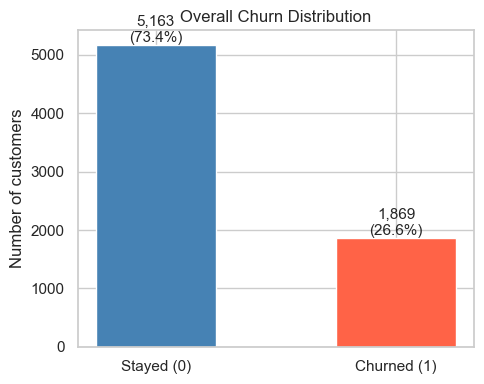

In [4]:
# Overall churn distribution
fig, ax = plt.subplots(figsize=(5, 4))
churn_counts = df['Churn'].value_counts()
ax.bar(['Stayed (0)', 'Churned (1)'], churn_counts.values,
       color=['steelblue', 'tomato'], width=0.5)
ax.set_ylabel('Number of customers')
ax.set_title('Overall Churn Distribution')
for i, v in enumerate(churn_counts.values):
    ax.text(i, v + 50, f'{v:,}\n({v/len(df):.1%})', ha='center', fontsize=11)
plt.tight_layout()
plt.show()

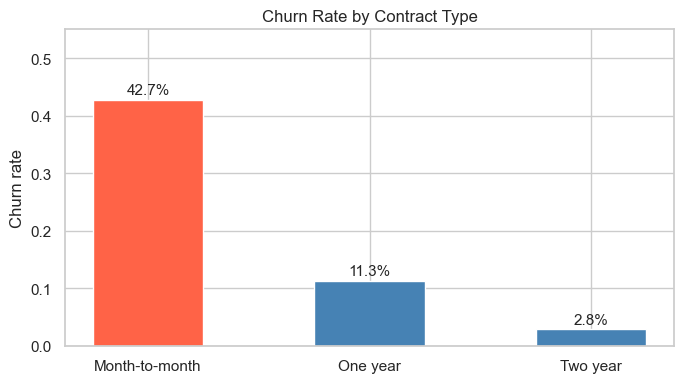

Contract
Month-to-month    0.427097
One year          0.112772
Two year          0.028487
Name: Churn, dtype: float64


In [5]:
# Churn rate by contract type
contract_churn = df.groupby('Contract')['Churn'].mean().sort_values(ascending=False)

fig, ax = plt.subplots(figsize=(7, 4))
bars = ax.bar(contract_churn.index, contract_churn.values,
              color=['tomato', 'steelblue', 'steelblue'], width=0.5)
ax.set_ylabel('Churn rate')
ax.set_title('Churn Rate by Contract Type')
ax.set_ylim(0, 0.55)
for bar, val in zip(bars, contract_churn.values):
    ax.text(bar.get_x() + bar.get_width()/2, val + 0.01,
            f'{val:.1%}', ha='center', fontsize=11)
plt.tight_layout()
plt.show()
print(contract_churn)

Month-to-month customers churn at ~43% vs ~3% for two-year contracts — a 14x difference. Contract type is the single strongest churn driver in this dataset.

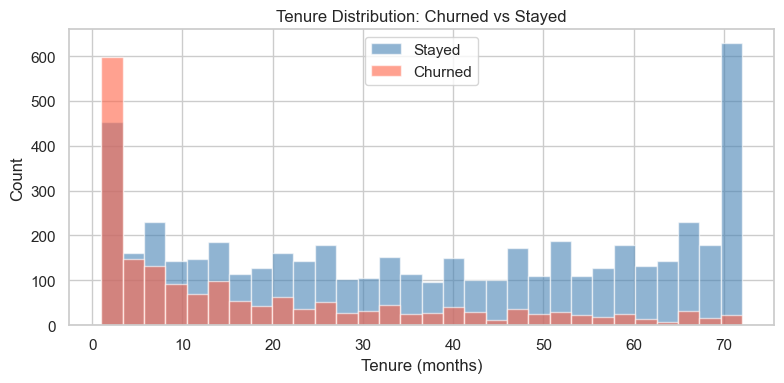

Avg tenure — Stayed:  37.7 months
Avg tenure — Churned: 18.0 months


In [6]:
# Churn by tenure
fig, ax = plt.subplots(figsize=(8, 4))
ax.hist(df[df['Churn']==0]['tenure'], bins=30, alpha=0.6, label='Stayed', color='steelblue')
ax.hist(df[df['Churn']==1]['tenure'], bins=30, alpha=0.6, label='Churned', color='tomato')
ax.set_xlabel('Tenure (months)')
ax.set_ylabel('Count')
ax.set_title('Tenure Distribution: Churned vs Stayed')
ax.legend()
plt.tight_layout()
plt.show()

print(f'Avg tenure — Stayed:  {df[df["Churn"]==0]["tenure"].mean():.1f} months')
print(f'Avg tenure — Churned: {df[df["Churn"]==1]["tenure"].mean():.1f} months')

Churned customers cluster heavily in the first 0–12 months. Average tenure is ~38 months for customers who stayed vs ~18 months for those who churned — the first year is the highest-risk window.

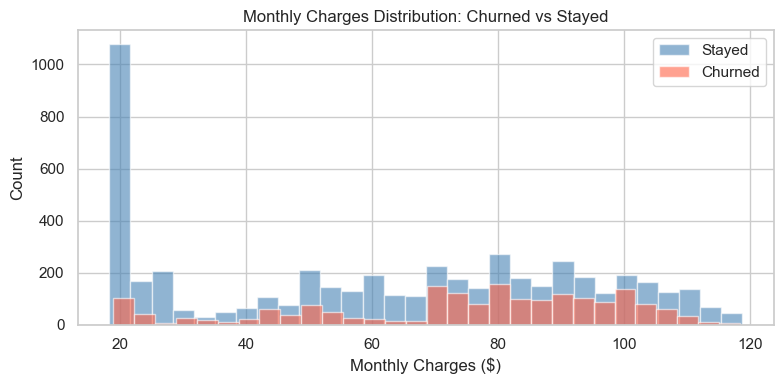

Avg monthly charge — Stayed:  $61.31
Avg monthly charge — Churned: $74.44


In [7]:
# Churn by monthly charges
fig, ax = plt.subplots(figsize=(8, 4))
ax.hist(df[df['Churn']==0]['MonthlyCharges'], bins=30, alpha=0.6, label='Stayed', color='steelblue')
ax.hist(df[df['Churn']==1]['MonthlyCharges'], bins=30, alpha=0.6, label='Churned', color='tomato')
ax.set_xlabel('Monthly Charges ($)')
ax.set_ylabel('Count')
ax.set_title('Monthly Charges Distribution: Churned vs Stayed')
ax.legend()
plt.tight_layout()
plt.show()

print(f'Avg monthly charge — Stayed:  ${df[df["Churn"]==0]["MonthlyCharges"].mean():.2f}')
print(f'Avg monthly charge — Churned: ${df[df["Churn"]==1]["MonthlyCharges"].mean():.2f}')

Churned customers pay ~$13/month more on average ($74 vs $61), suggesting a value perception issue — higher-paying customers may not feel the service justifies the cost.

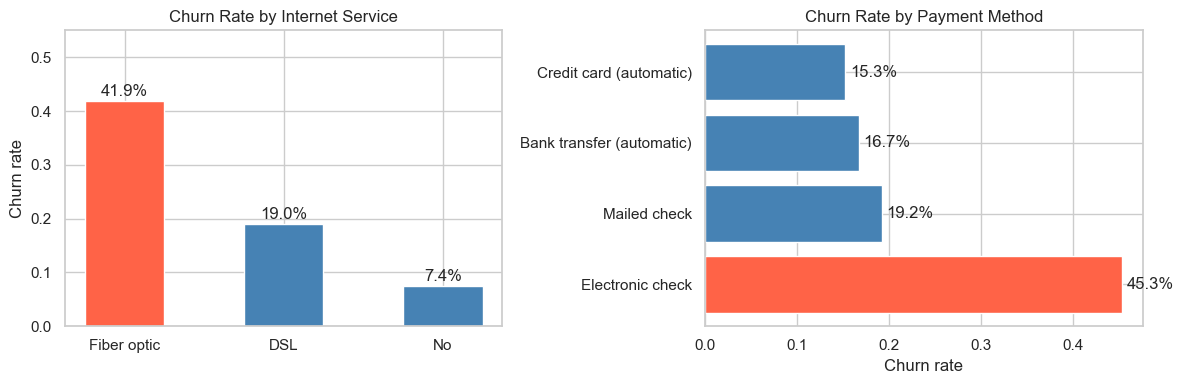

In [8]:
# Churn by internet service and payment method
fig, axes = plt.subplots(1, 2, figsize=(12, 4))

internet_churn = df.groupby('InternetService')['Churn'].mean().sort_values(ascending=False)
axes[0].bar(internet_churn.index, internet_churn.values,
            color=['tomato', 'steelblue', 'steelblue'], width=0.5)
axes[0].set_title('Churn Rate by Internet Service')
axes[0].set_ylabel('Churn rate')
axes[0].set_ylim(0, 0.55)
for i, v in enumerate(internet_churn.values):
    axes[0].text(i, v + 0.01, f'{v:.1%}', ha='center')

pay_churn = df.groupby('PaymentMethod')['Churn'].mean().sort_values(ascending=False)
axes[1].barh(pay_churn.index, pay_churn.values,
             color=['tomato', 'steelblue', 'steelblue', 'steelblue'])
axes[1].set_title('Churn Rate by Payment Method')
axes[1].set_xlabel('Churn rate')
for i, v in enumerate(pay_churn.values):
    axes[1].text(v + 0.005, i, f'{v:.1%}', va='center')

plt.tight_layout()
plt.show()

Fiber optic customers churn at ~42% — likely reflecting stronger competition or service quality issues at that tier. Electronic check payers churn at ~45% vs ~15% for auto-pay methods, suggesting that payment friction correlates with lower commitment.

---
## 4. Feature Engineering

I created two features grounded in the EDA findings above.

In [9]:
# Average monthly spend over lifetime (handles tenure=0 edge case)
df['avg_monthly_spend'] = df['TotalCharges'] / df['tenure'].replace(0, 1)

# Binary flag encoding the high-risk first-year window identified in EDA
df['is_new_customer'] = (df['tenure'] <= 12).astype(int)

print('Churn rate by customer age group:')
print(df.groupby('is_new_customer')['Churn'].mean()
        .rename({0: 'Established (>12 months)', 1: 'New (<=12 months)'}))

Churn rate by customer age group:
is_new_customer
Established (>12 months)    0.171299
New (<=12 months)           0.476782
Name: Churn, dtype: float64


New customers (≤12 months) churn at roughly 2x the rate of established customers, confirming `is_new_customer` as a useful predictive feature.

---
## 5. Prepare Data for Modeling

In [10]:
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler

# One-hot encode categorical features (drop_first avoids multicollinearity)
df_model = pd.get_dummies(df, drop_first=True)

X = df_model.drop(columns=['Churn'])
y = df_model['Churn']

# Stratified split preserves the ~26% churn ratio in both sets
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y
)

# Scale numeric features — fit on train only to prevent data leakage
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled  = scaler.transform(X_test)

print(f'Train: {X_train.shape[0]} rows | Test: {X_test.shape[0]} rows | Features: {X_train.shape[1]}')
print(f'Churn rate — train: {y_train.mean():.1%} | test: {y_test.mean():.1%}')

Train: 5625 rows | Test: 1407 rows | Features: 32
Churn rate — train: 26.6% | test: 26.6%


The scaler is fitted on training data only and applied (transformed) to the test set — fitting on the full dataset would leak test information into the scaling parameters and inflate evaluation metrics.

---
## 6. Modeling

I trained two models and compared them. Both use `class_weight='balanced'` to account for the 74/26 class imbalance — this prevents the model from simply predicting "no churn" for everyone.

In [11]:
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import (classification_report, confusion_matrix,
                             roc_auc_score, RocCurveDisplay)

# Logistic Regression — interpretable baseline
lr = LogisticRegression(class_weight='balanced', max_iter=1000, random_state=42)
lr.fit(X_train_scaled, y_train)
lr_preds = lr.predict(X_test_scaled)
lr_proba = lr.predict_proba(X_test_scaled)[:, 1]

# Random Forest — captures non-linear patterns
rf = RandomForestClassifier(n_estimators=100, class_weight='balanced',
                            random_state=42, n_jobs=-1)
rf.fit(X_train, y_train)
rf_preds = rf.predict(X_test)
rf_proba = rf.predict_proba(X_test)[:, 1]

print('=== Logistic Regression ===')
print(classification_report(y_test, lr_preds, target_names=['Stayed', 'Churned']))
print(f'ROC-AUC: {roc_auc_score(y_test, lr_proba):.3f}')

print('\n=== Random Forest ===')
print(classification_report(y_test, rf_preds, target_names=['Stayed', 'Churned']))
print(f'ROC-AUC: {roc_auc_score(y_test, rf_proba):.3f}')

=== Logistic Regression ===
              precision    recall  f1-score   support

      Stayed       0.90      0.70      0.79      1033
     Churned       0.49      0.79      0.60       374

    accuracy                           0.72      1407
   macro avg       0.70      0.75      0.70      1407
weighted avg       0.79      0.72      0.74      1407

ROC-AUC: 0.833

=== Random Forest ===
              precision    recall  f1-score   support

      Stayed       0.83      0.89      0.86      1033
     Churned       0.62      0.49      0.55       374

    accuracy                           0.79      1407
   macro avg       0.73      0.69      0.70      1407
weighted avg       0.77      0.79      0.78      1407

ROC-AUC: 0.818


---
## 7. Model Evaluation

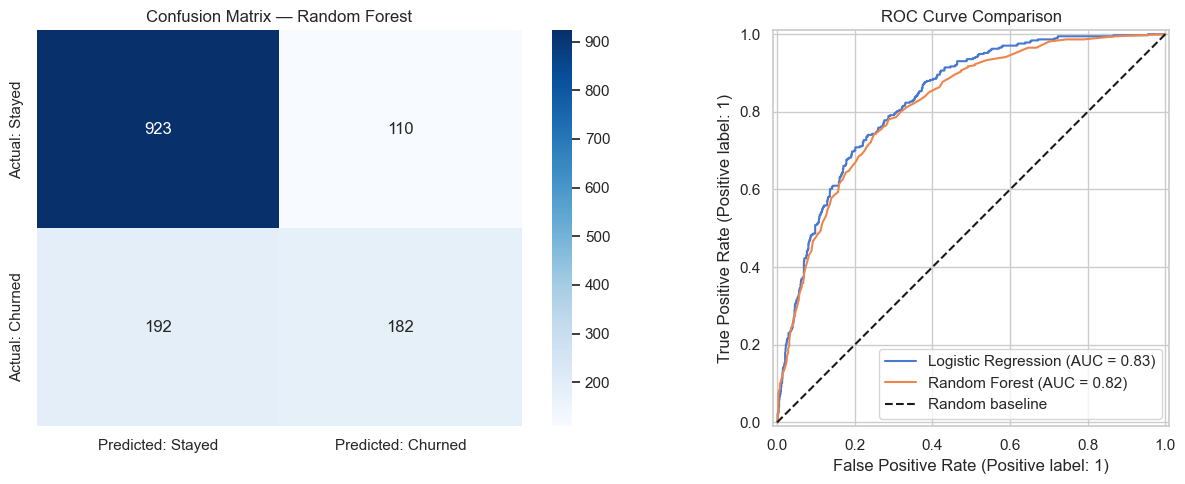

In [13]:
fig, axes = plt.subplots(1, 2, figsize=(13, 5))

# Confusion matrix
cm = confusion_matrix(y_test, rf_preds)
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', ax=axes[0],
            xticklabels=['Predicted: Stayed', 'Predicted: Churned'],
            yticklabels=['Actual: Stayed', 'Actual: Churned'])
axes[0].set_title('Confusion Matrix — Random Forest')

# ROC curves
RocCurveDisplay.from_predictions(y_test, lr_proba, name='Logistic Regression', ax=axes[1])
RocCurveDisplay.from_predictions(y_test, rf_proba, name='Random Forest', ax=axes[1])
axes[1].plot([0,1],[0,1],'k--', label='Random baseline')
axes[1].set_title('ROC Curve Comparison')
axes[1].legend()

plt.tight_layout()
plt.show()

Logistic Regression achieves a higher ROC-AUC (0.833 vs 0.818) and significantly 
better churn recall (0.79 vs 0.49), meaning it catches nearly twice as many 
at-risk customers as Random Forest. For churn prediction, recall on the churned 
class is the priority — missing an at-risk customer is more costly than sending 
a retention offer to someone who would have stayed anyway. The false negatives 
(bottom-left of the confusion matrix) represent customers we failed to flag and 
are the most expensive errors in this business context.

---
## 8. Feature Importance

In [ ]:
importances = pd.Series(rf.feature_importances_, index=X_train.columns)
top_features = importances.sort_values(ascending=False).head(15)

fig, ax = plt.subplots(figsize=(8, 6))
top_features.sort_values().plot(kind='barh', ax=ax, color='steelblue')
ax.set_title('Top 15 Features Driving Churn (Random Forest)')
ax.set_xlabel('Feature Importance')
plt.tight_layout()
plt.show()

print('Top 10 churn drivers:')
print(top_features.head(10).to_string())

---
## 9. Findings & Business Recommendations

### Key findings

| Driver | Finding |
|--------|---------|
| Contract type | Month-to-month customers churn at ~43% vs ~3% for two-year contracts |
| Tenure | Customers in their first 12 months churn at ~2x the rate of established customers |
| Monthly charges | Churners pay ~$13/month more on average ($74 vs $61) |
| Payment method | Electronic check payers churn at ~45% vs ~15% for auto-pay methods |
| Internet service | Fiber optic customers churn at ~42% vs ~19% for DSL |

### Recommendations

**1. Prioritize contract upgrades**  
Design incentives to move month-to-month customers to one-year contracts. The ~32 percentage point reduction in churn risk more than justifies a moderate discount.

**2. Build a 90-day onboarding program**  
The first 12 months are the highest-risk window. Proactive check-ins and early engagement touchpoints can meaningfully reduce early churn.

**3. Incentivize auto-pay at signup**  
Electronic check payers churn at nearly 3x the rate of auto-pay customers. A small discount ($5/month) for enrolling in automatic payment could reduce churn significantly.

**4. Investigate fiber optic service quality**  
Fiber customers pay more and churn more — a value perception problem. A targeted NPS survey of this segment is a logical next step.

**5. Deploy model as a monthly risk score**  
Use the Logistic Regression model (ROC-AUC 0.833) to score all customers monthly and route the top at-risk accounts to the retention team for proactive outreach.

| Model | ROC-AUC | Churn Recall | Churn Precision |
|-------|---------|-------------|----------------|
| Logistic Regression | 0.833 | 0.79 | 0.49 |
| Random Forest | 0.818 | 0.49 | 0.62 |

**Logistic Regression is recommended for deployment** — it outperforms Random 
Forest on both ROC-AUC (0.833 vs 0.818) and churn recall (0.79 vs 0.49), 
meaning it catches more at-risk customers. It is also faster to score at scale 
and its coefficients are directly interpretable for non-technical stakeholders.

Interestingly, the simpler logistic regression outperformed random forest on recall for the churned class — 79% vs 49%. That told me the relationships in this data are largely linear, and adding model complexity wasn't helping. So I recommended logistic regression for deployment.

---
**Deepti Dhanapala** — Data Scientist | MPS Data Science, University at Buffalo (Feb 2026)  
[LinkedIn](https://linkedin.com/in/deeptidhanpal) · [GitHub](https://github.com/Deepti-Dhanapala)